# Pertemuan 13 - Pengantar Deep Learning & NLP Dasar
Nama : Abdul Zaki Al-Muttaqin
Nim : 240401010042
Kelas : IF403

## Tujuan Praktikum
Praktikum ini bertujuan untuk memahami dasar penggunaan Deep Learning dan Natural Language Processing (NLP). Pada bagian Deep Learning, dilakukan pembuatan dan pelatihan Neural Network untuk mengklasifikasikan data non-linear. Selanjutnya, pada bagian NLP dilakukan pengolahan ulasan produk menggunakan TF-IDF dan klasifikasi sentimen menggunakan Logistic Regression.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

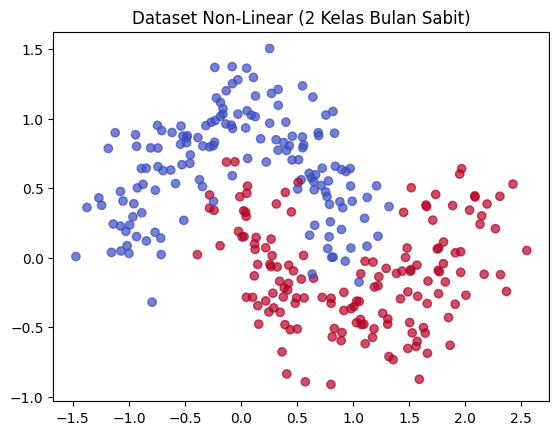

In [ ]:
# Generate & Eksplorasi Dataset Non-Linear
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

In [ ]:
# Bangun & Latih Neural Network Sederhana
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.900


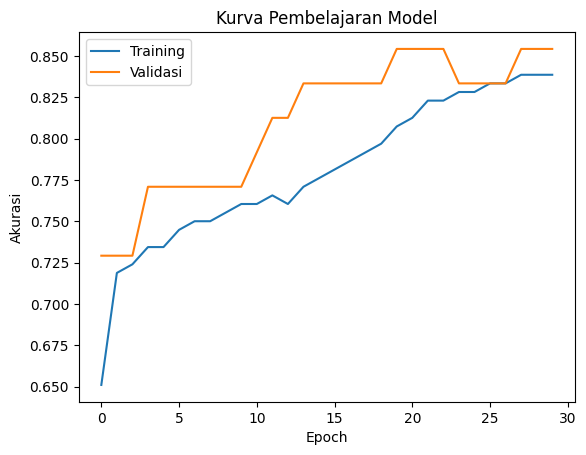

In [ ]:
# Evaluasi model pada data testing
loss, acc = model.evaluate(X_te, y_te, verbose=0)

print(f'Akurasi pada data uji: {acc:.3f}')

# Visualisasi kurva pembelajaran
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')

plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()


In [ ]:
# Siapkan Dataset Ulasan Produk
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',

    'Produk bagus dan berkualitas',
    'Pelayanannya cepat dan ramah',
    'Barang sesuai dengan pesanan',
    'Kualitas produknya sangat baik',
    'Saya sangat puas dengan pembelian ini',
    'Pengiriman cepat dan barang aman',
    'Produk bagus, saya suka',
    'Harga murah dan kualitas bagus',
    'Barang datang tepat waktu',
    'Sangat recommended untuk dibeli',
    'Kualitas sesuai dengan harga',
    'Produk sangat memuaskan',
    'Barangnya lengkap dan bagus',
    'Saya akan membeli lagi',

    'Barang tidak bagus dan mengecewakan',
    'Pengiriman sangat lambat',
    'Produk rusak ketika diterima',
    'Kualitas barang sangat buruk',
    'Tidak sesuai dengan deskripsi',
    'Saya tidak puas dengan produk ini',
    'Barang berbeda dari foto',
    'Harga terlalu mahal untuk kualitas seperti ini',
    'Produk mengecewakan',
    'Barang datang terlambat',
    'Kualitas tidak sesuai harapan',
    'Saya kecewa dengan pembelian ini',
    'Produk tidak berfungsi dengan baik',
    'Barang cacat saat diterima',
    'Tidak recommended untuk dibeli',
    'Pelayanan sangat buruk',
    'Produk kurang bagus',
    'Barang tidak sesuai pesanan',
    'Saya tidak akan membeli lagi',
    'Sangat kecewa dengan produknya'
]

label = [
    1, 0, 1, 0, 1, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]

print('Jumlah ulasan:', len(ulasan))
print('Jumlah label:', len(label))

Jumlah ulasan: 40
Jumlah label: 40


In [ ]:
# Ubah Teks Menjadi TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 64
['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'beli'
 'berbeda' 'berfungsi']


In [ ]:
# Latih Model Klasifikasi Sentimen & Evaluasi
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.375
Positif


# Kesimpulan

Pada praktikum ini saya mempelajari dasar Natural Language Processing (NLP) untuk melakukan analisis sentimen. Teks ulasan diubah menjadi bentuk angka menggunakan TF-IDF, kemudian digunakan sebagai input untuk model Logistic Regression.

Hasil pengujian menunjukkan bahwa model mendapatkan akurasi sebesar 100% pada data testing. Model juga berhasil memprediksi kalimat baru sebagai sentimen positif.

Namun, hasil tersebut masih memiliki keterbatasan karena jumlah data yang digunakan hanya 40 ulasan dan datanya masih sederhana. Oleh karena itu, akurasi 100% belum tentu menunjukkan bahwa model akan memiliki hasil yang sama jika digunakan pada dataset yang lebih besar dan beragam.